
Gefundene Messblöcke: 1


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.001102
Amplitude   20 Hz:     0.000976
Amplitude   30 Hz:     0.000976
Amplitude   40 Hz:     0.045614
Amplitude   50 Hz:     0.104667


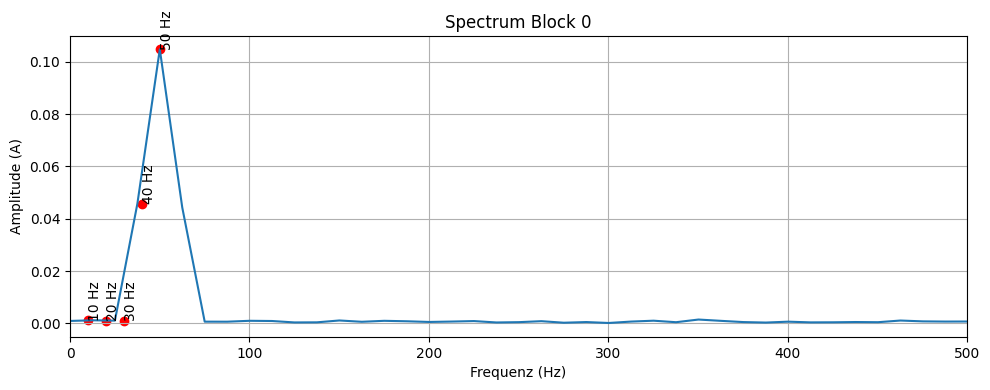

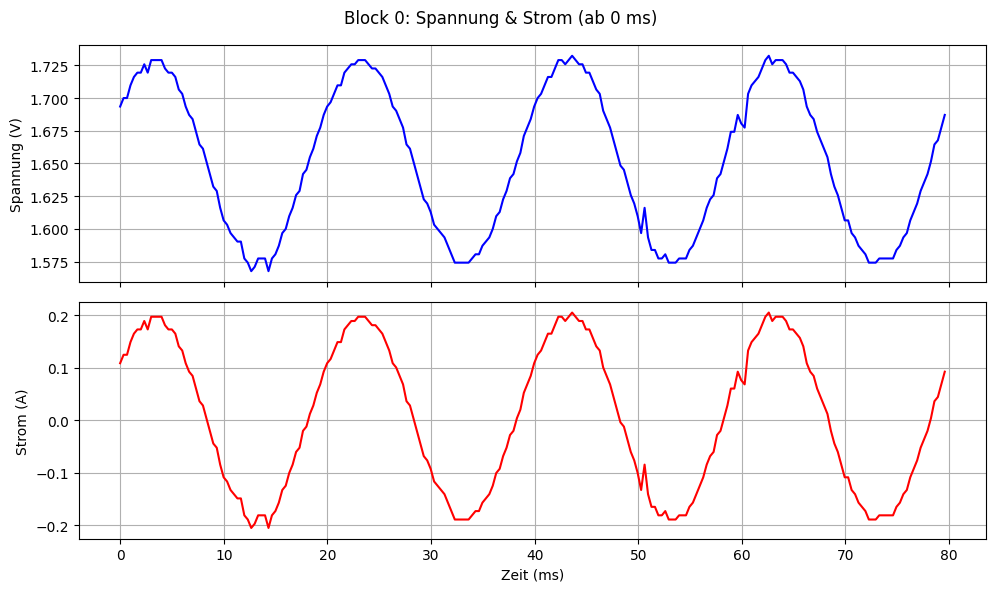


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.137815 A
I_max:                    0.205600 A
P ≈ I_rms * 220 V:        30.319 W

Feature-Vektor:
[0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]


===== Alle Feature-Vektoren =====
Block 0: [0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "ventelator.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac *window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [10,20, 30, 40, 50]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"], color="red")
    axI.set_ylabel("Strom (A)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")



Gefundene Messblöcke: 1


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            216
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.00 Hz
Blockdauer:               0.0716 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.242609
Amplitude  100 Hz:     0.022163
Amplitude  150 Hz:     0.301038
Amplitude  200 Hz:     0.022659
Amplitude  250 Hz:     0.302214


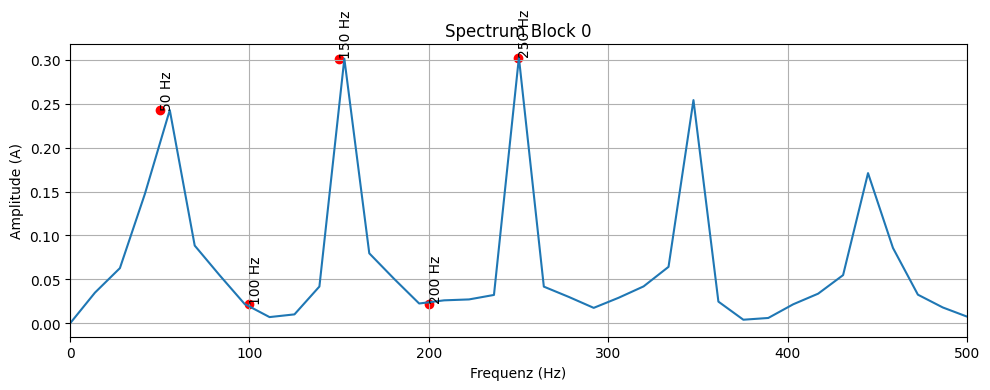

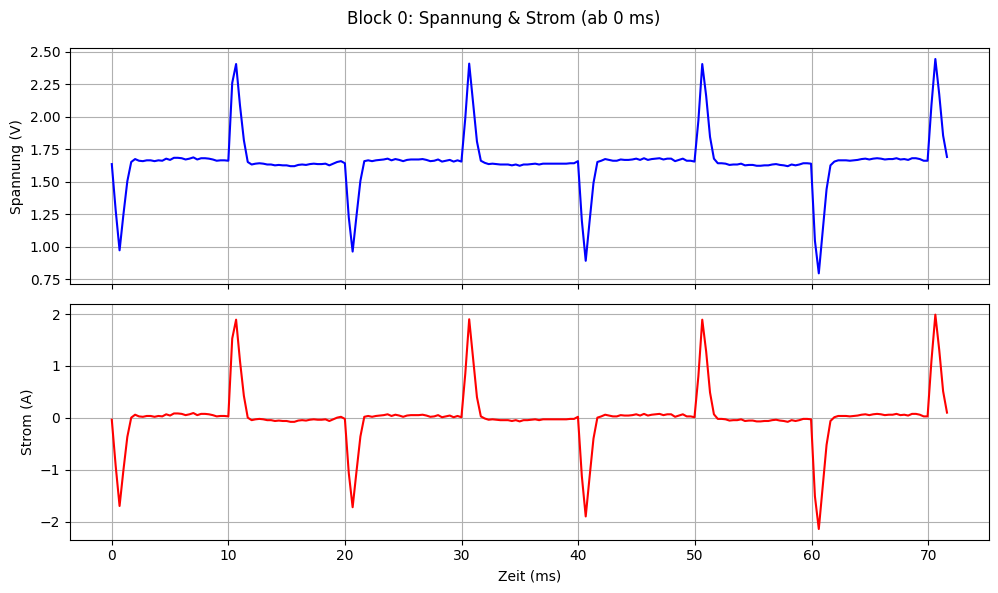


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.491182 A
I_max:                    2.141100 A
P ≈ I_rms * 220 V:        108.060 W

Feature-Vektor:
[0.49118241222923825, 2.1411, 0.2426092374359547, 0.022162600536023844, 0.3010384266336124, 0.02265880964622666, 0.3022142315620162]


===== Alle Feature-Vektoren =====
Block 0: [0.49118241222923825, 2.1411, 0.2426092374359547, 0.022162600536023844, 0.3010384266336124, 0.02265880964622666, 0.3022142315620162]


===== Alle Feature-Vektoren =====
Block 0: [0.49118241222923825, 2.1411, 0.2426092374359547, 0.022162600536023844, 0.3010384266336124, 0.02265880964622666, 0.3022142315620162]

CSV-Dateien gespeichert:
 -> x_values.csv   (Features)
 -> y_values.csv   (Labels)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================
# 1️⃣ Liste deiner drei Geräte-Dateien + Label
# ============================================
device_files = [
    ("geraet1.txt", 0),   # Gerät 0
    ("geraet2.txt", 1),   # Gerät 1
    ("geraet3.txt", 2)    # Gerät 2
]


# Gesamtspeicher für alle Featurevektoren
ALL_FEATURES = []
ALL_LABELS = []


# ============================================
# 2️⃣ Funktion: eine Datei einlesen & verarbeiten
# ============================================
def process_file(filename, device_label):

    print("\n=======================================")
    print(f"     VERARBEITE DATEI: {filename}")
    print("=======================================\n")

    df = pd.read_csv(
        filename,
        sep=r"\s+",
        header=None,
        names=["time_us", "voltage_V", "current_A"]
    )

    # Zeit berechnen
    df["time_s"] = df["time_us"] * 1e-6

    # === Blockerkennung
    dt = df["time_us"].diff()
    threshold = 2 * dt.median()
    df["block"] = (dt > threshold).cumsum()

    n_blocks = df["block"].max() + 1
    print(f"Gefundene Messblöcke: {n_blocks}")

    # Liste für diese Datei
    local_features = []

    # ============================================
    # 3️⃣ Verarbeitung jedes einzelnen Blockes
    # ============================================
    for blk, d in df.groupby("block"):
        print(f"\n===============================")
        print(f"       BLOCK {blk}")
        print(f"===============================")

        # Zeit normalisieren
        time_s = d["time_s"].to_numpy()
        time_s = time_s - time_s[0]

        dt_s = np.diff(time_s)
        mean_dt_s = dt_s.mean()
        fs_real = 1.0 / mean_dt_s

        print("----- Abtastraten-Analyse -----")
        print(f"Punkte:               {len(d)}")
        print(f"Δt Mittelwert:        {mean_dt_s*1e6:.3f} µs")
        print(f"Reale Abtastrate:     {fs_real:.2f} Hz")
        print(f"Blockdauer:           {time_s[-1]:.4f} s")

        # Stromsignal
        I = d["current_A"].to_numpy()
        I_ac = I - I.mean()

        # FFT
        N = len(I_ac)
        window = np.hamming(N)
        I_win = I_ac * window

        freqs = np.fft.rfftfreq(N, d=mean_dt_s)
        I_fft = np.fft.rfft(I_win)
        mag = np.abs(I_fft) * 2.0 / N

        # Frequenzen für Features
        freq_targets = [50, 100, 150, 200, 250]
        amps = []

        print("\n----- Spektrale Merkmale -----")
        for f in freq_targets:
            idx = np.argmin(np.abs(freqs - f))
            amps.append(mag[idx])
            print(f"{f:4} Hz Amplitude: {mag[idx]:.6f}")

        # Spektrum plotten
        plt.figure(figsize=(10, 4))
        plt.plot(freqs, mag)
        for f, a in zip(freq_targets, amps):
            plt.scatter(f, a, color="red")
        plt.xlim(0, 500)
        plt.title(f"Spectrum Block {blk} ({filename})")
        plt.xlabel("Frequenz (Hz)")
        plt.ylabel("Amplitude (A)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Zeitbereich plotten
        time_ms = time_s * 1000

        fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        axV.plot(time_ms, d["voltage_V"])
        axV.set_ylabel("Spannung (V)")
        axV.grid(True)

        axI.plot(time_ms, d["current_A"], color="red")
        axI.set_ylabel("Strom (A)")
        axI.set_xlabel("Zeit (ms)")
        axI.grid(True)

        plt.suptitle(f"Block {blk} – {filename}")
        plt.tight_layout()
        plt.show()

        # === Zeitbereichsmerkmale
        I_rms = np.sqrt(np.mean(I**2))
        I_max = np.max(np.abs(I))

        print("\n----- Zeitbereichs-Merkmale -----")
        print(f"I_RMS: {I_rms:.6f} A")
        print(f"I_MAX: {I_max:.6f} A")

        # === Featurevektor
        feature_vec = [I_rms, I_max] + amps
        local_features.append(feature_vec)

        print("Feature-Vektor:", feature_vec)

    # === lokale Features global speichern ===
    for fv in local_features:
        ALL_FEATURES.append(fv)
        ALL_LABELS.append(device_label)


# ============================================
# 4️⃣ Verarbeitung aller 3 Geräte
# ============================================
for filename, label in device_files:
    process_file(filename, label)


# ============================================
# 5️⃣ CSV-Dateien erzeugen
# ============================================
feature_df = pd.DataFrame(
    ALL_FEATURES,
    columns=[
        "I_RMS", "I_MAX",
        "Amp_50Hz", "Amp_100Hz", "Amp_150Hz", "Amp_200Hz", "Amp_250Hz"
    ]
)

label_df = pd.DataFrame(ALL_LABELS, columns=["label"])

feature_df.to_csv("x_values.csv", index=False)
label_df.to_csv("y_values.csv", index=False)

print("\n----------------------------------")
print("CSV-Dateien wurden erzeugt!")
print("  -> x_values.csv  (Feature-Vektoren)")
print("  -> y_values.csv  (Labels: 0,1,2)")
print("----------------------------------")



Gefundene Messblöcke: 6


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            38
Mittlerer Abstand:        333.03 µs
Reale Abtastrate:         3002.76 Hz
Blockdauer:               0.0123 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.044549
Amplitude  100 Hz:     0.044549
Amplitude  150 Hz:     0.072409
Amplitude  200 Hz:     0.057537
Amplitude  250 Hz:     0.057537


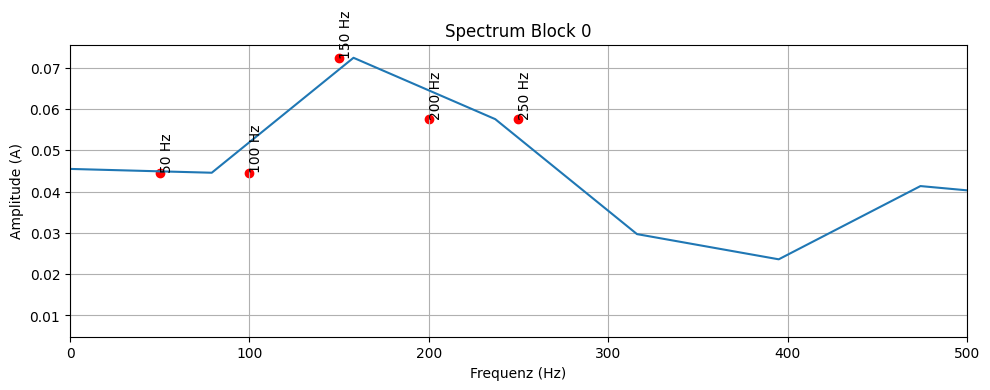

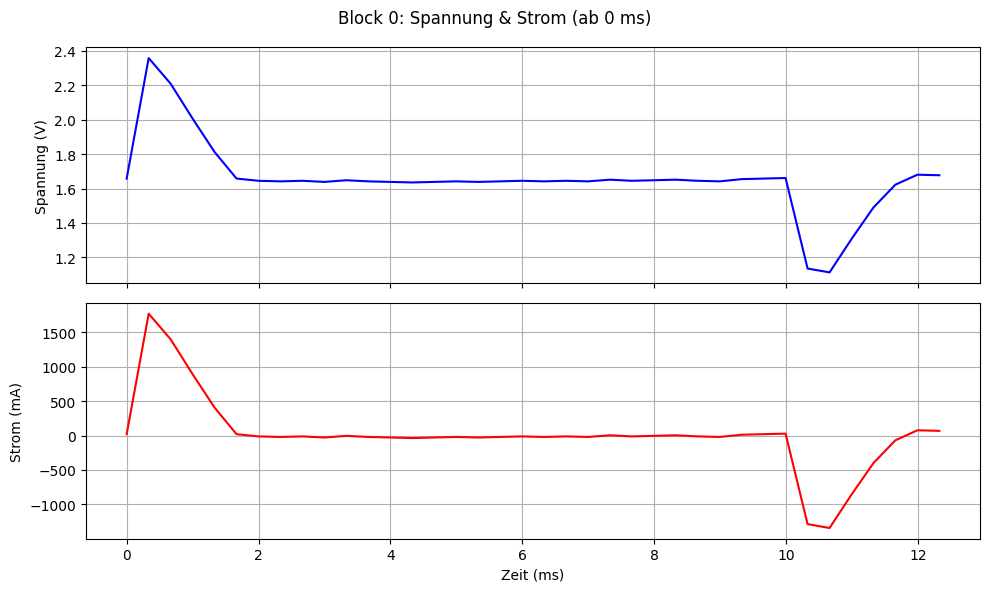


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.523940 A
I_max:                    1.770200 A
P ≈ I_rms * 220 V:        115.267 W

Feature-Vektor:
[0.5239404654307486, 1.7702, 0.044548765721409395, 0.044548765721409395, 0.07240881866544792, 0.05753711505969425, 0.05753711505969425]

        BLOCK 1
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.172060
Amplitude  100 Hz:     0.002750
Amplitude  150 Hz:     0.160302
Amplitude  200 Hz:     0.001612
Amplitude  250 Hz:     0.142445


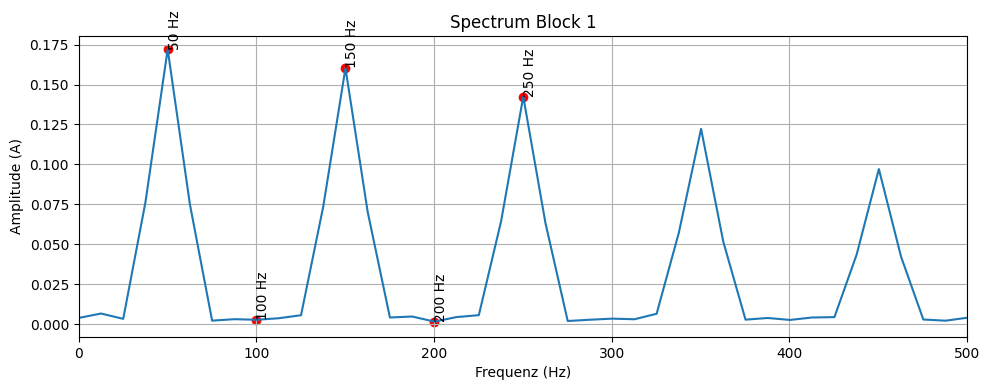

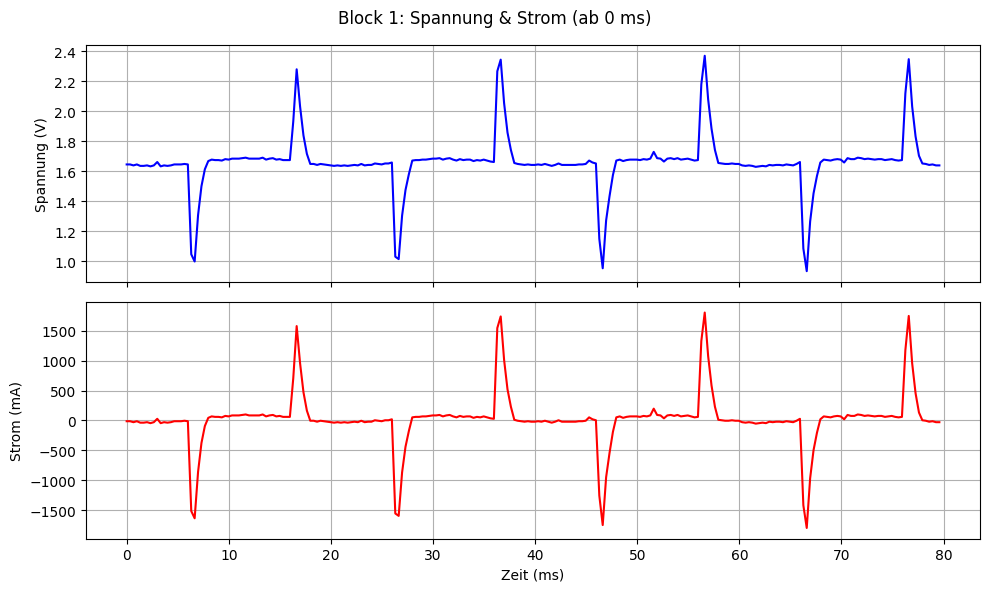


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.445743 A
I_max:                    1.802400 A
P ≈ I_rms * 220 V:        98.063 W

Feature-Vektor:
[0.4457429102539564, 1.8024, 0.17206041335910982, 0.00274999182112823, 0.16030155361842027, 0.0016118746615680995, 0.14244546393182603]

        BLOCK 2
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.169498
Amplitude  100 Hz:     0.006171
Amplitude  150 Hz:     0.158734
Amplitude  200 Hz:     0.007534
Amplitude  250 Hz:     0.144139


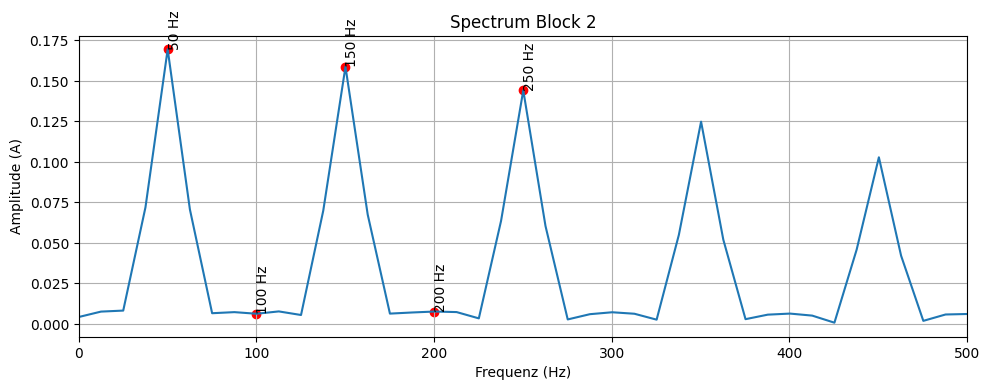

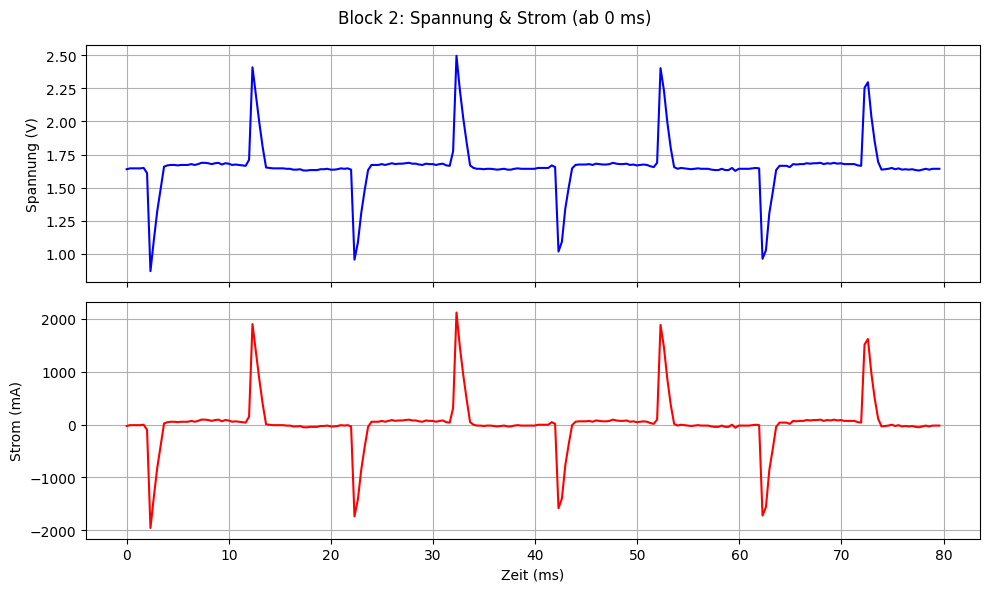


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.462929 A
I_max:                    2.116900 A
P ≈ I_rms * 220 V:        101.844 W

Feature-Vektor:
[0.46292946884487707, 2.1169, 0.1694975055962357, 0.006171091281943195, 0.1587336060960851, 0.007534279156778788, 0.14413905450028466]

        BLOCK 3
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.183188
Amplitude  100 Hz:     0.001695
Amplitude  150 Hz:     0.172174
Amplitude  200 Hz:     0.002968
Amplitude  250 Hz:     0.154127


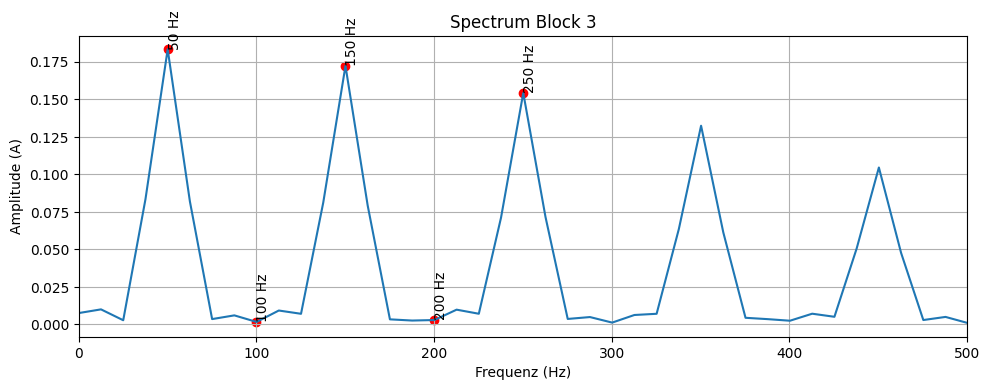

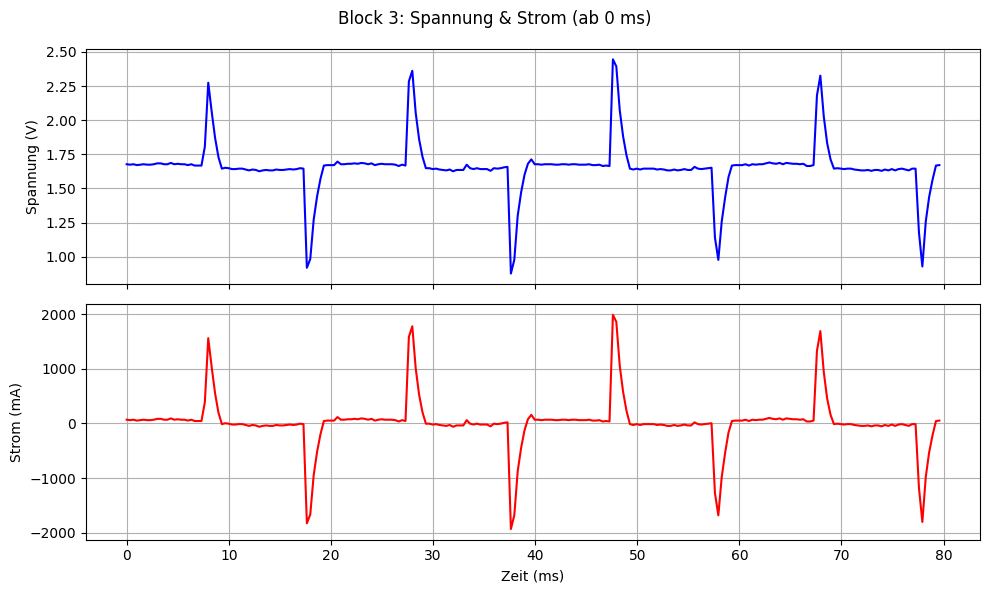


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.468795 A
I_max:                    1.987900 A
P ≈ I_rms * 220 V:        103.135 W

Feature-Vektor:
[0.46879542095495486, 1.9879, 0.18318825621250662, 0.0016952185669954188, 0.17217354552740638, 0.0029675793678650034, 0.1541269425877873]

        BLOCK 4
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.141879
Amplitude  100 Hz:     0.002240
Amplitude  150 Hz:     0.132585
Amplitude  200 Hz:     0.003173
Amplitude  250 Hz:     0.120796


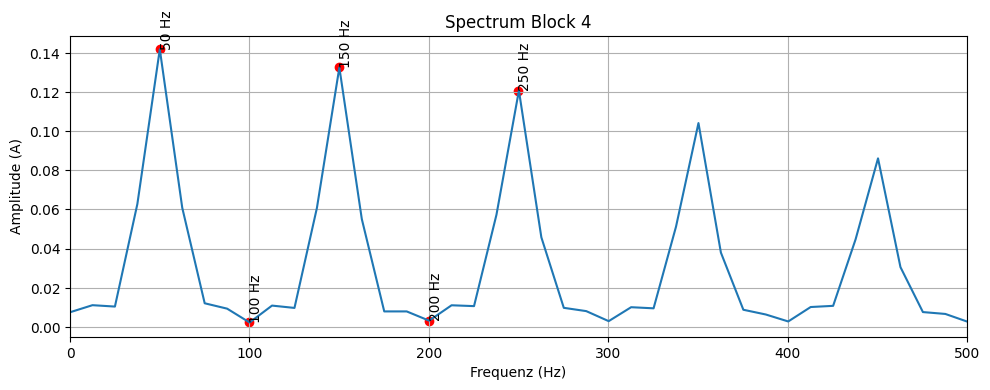

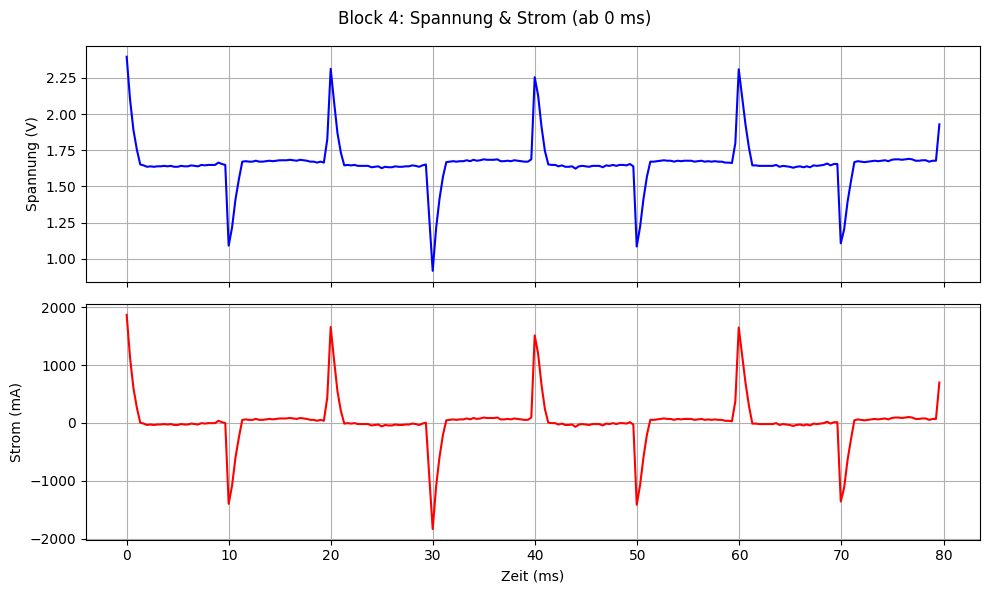


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.388113 A
I_max:                    1.866900 A
P ≈ I_rms * 220 V:        85.385 W

Feature-Vektor:
[0.38811318001325334, 1.8669, 0.14187910771440201, 0.002240404983864576, 0.13258474780125937, 0.0031728905901209402, 0.1207956748563121]

        BLOCK 5
----- Abtastraten-Analyse -----
Anzahl Punkte:            17
Mittlerer Abstand:        332.87 µs
Reale Abtastrate:         3004.13 Hz
Blockdauer:               0.0053 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.196603
Amplitude  100 Hz:     0.309497
Amplitude  150 Hz:     0.309497
Amplitude  200 Hz:     0.309497
Amplitude  250 Hz:     0.309497


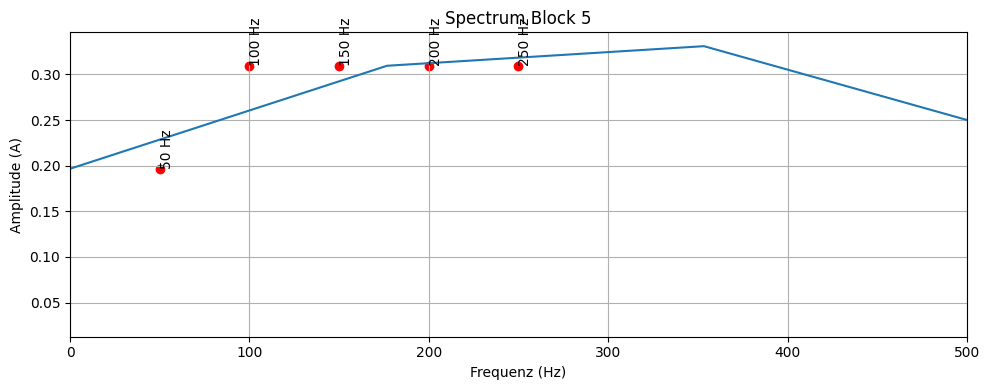

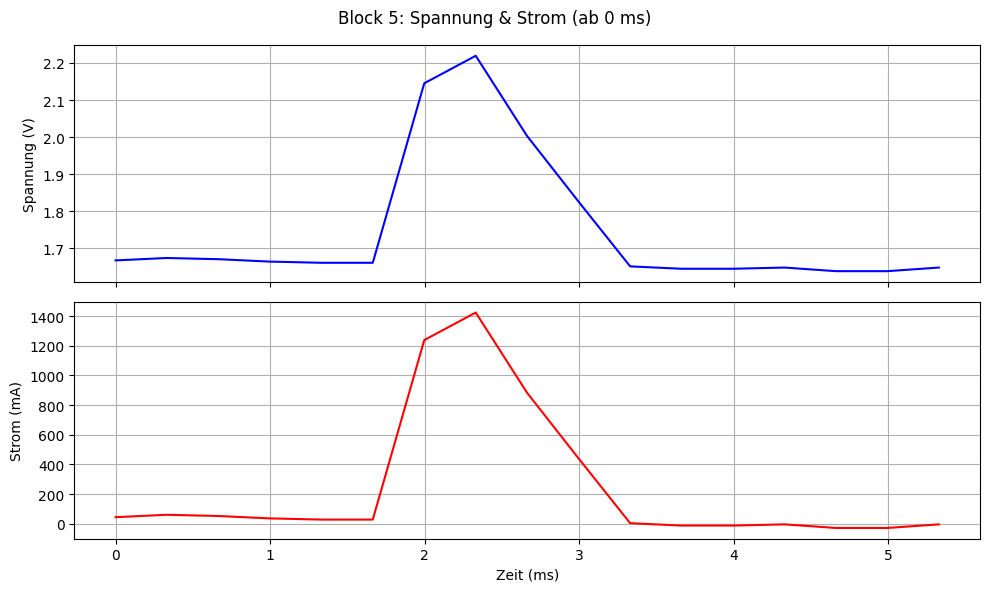


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.517045 A
I_max:                    1.423400 A
P ≈ I_rms * 220 V:        113.750 W

Feature-Vektor:
[0.5170451493540851, 1.4234, 0.1966026361622321, 0.3094966277065543, 0.3094966277065543, 0.3094966277065543, 0.3094966277065543]


===== Alle Feature-Vektoren =====
Block 0: [0.5239404654307486, 1.7702, 0.044548765721409395, 0.044548765721409395, 0.07240881866544792, 0.05753711505969425, 0.05753711505969425]
Block 1: [0.4457429102539564, 1.8024, 0.17206041335910982, 0.00274999182112823, 0.16030155361842027, 0.0016118746615680995, 0.14244546393182603]
Block 2: [0.46292946884487707, 2.1169, 0.1694975055962357, 0.006171091281943195, 0.1587336060960851, 0.007534279156778788, 0.14413905450028466]
Block 3: [0.46879542095495486, 1.9879, 0.18318825621250662, 0.0016952185669954188, 0.17217354552740638, 0.0029675793678650034, 0.1541269425877873]
Block 4: [0.38811318001325334, 1.8669, 0.14187910771440201, 0.002240404983864576, 0.132584747

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "lpt_netzteil1.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac * window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [50,100, 150, 200, 250]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"]*1000, color="red")
    axI.set_ylabel("Strom (mA)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")


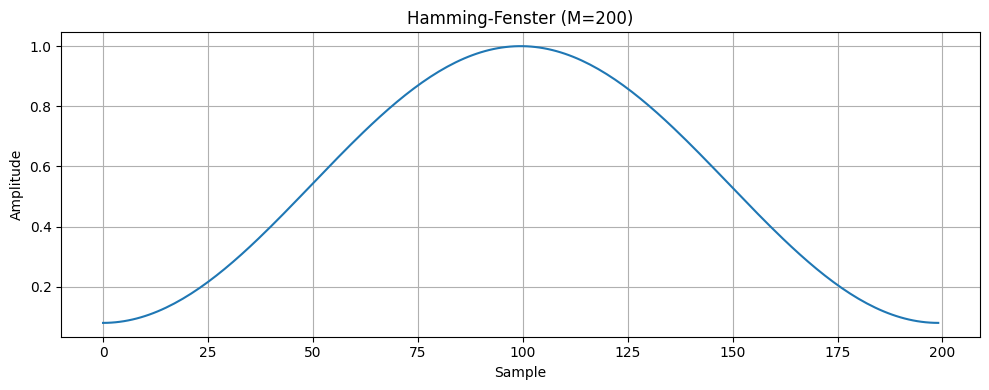

C:\Users\taleb\AppData\Local\Temp\ipykernel_13848\3766774030.py:31: RuntimeWarning: divide by zero encountered in log10
  mag_db = 20 * np.log10(np.abs(W_shift) / np.max(np.abs(W_shift)))


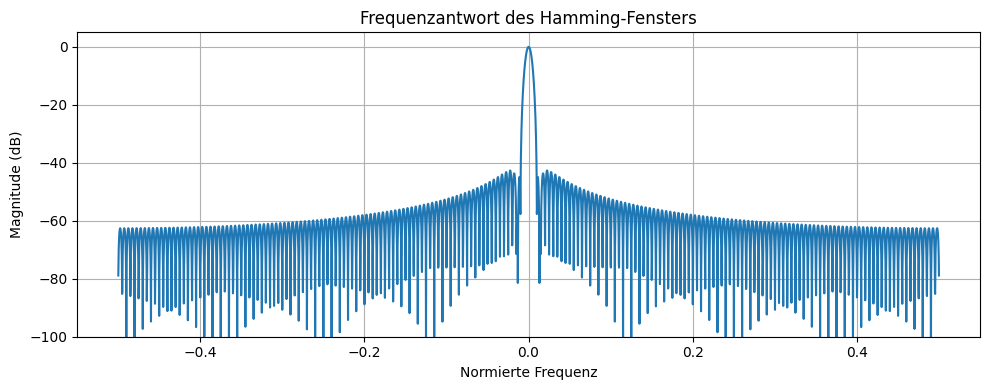

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hamming(M=200):
    """
    Plottet das Hamming-Fenster und seine Frequenzantwort.
    
    Parameter:
    ----------
    M : int
        Anzahl der Samples im Fenster
    """

    # --- 1. Hamming Fenster ---
    w = np.hamming(M)

    # --- Plot im Zeitbereich ---
    plt.figure(figsize=(10,4))
    plt.plot(w, label="Hamming Window")
    plt.title(f"Hamming-Fenster (M={M})")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- 2. Frequenzantwort ---
    W = np.fft.fft(w, 4096)
    W_shift = np.fft.fftshift(W)
    freq = np.linspace(-0.5, 0.5, len(W_shift))
    mag_db = 20 * np.log10(np.abs(W_shift) / np.max(np.abs(W_shift)))

    plt.figure(figsize=(10,4))
    plt.plot(freq, mag_db)
    plt.title("Frequenzantwort des Hamming-Fensters")
    plt.xlabel("Normierte Frequenz")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.ylim(-100, 5)
    plt.tight_layout()
    plt.show()


# Beispielaufruf
plot_hamming(200)
